In [5]:
# Run once in notebook
!pip install --quiet pandas numpy matplotlib seaborn scikit-learn xgboost catboost joblib statsmodels openpyxl
import os, warnings, math
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from math import sqrt

import xgboost as xgb
from catboost import CatBoostRegressor, Pool
import joblib

SEED = 42
np.random.seed(SEED)
OUTPUT_DIR = "ncrb_global_ensemble_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


Columns: ['States_UT', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2020', '2021', '2022']
Years detected: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2020, 2021, 2022]
States: 34, Years range: 2011-2022


Year,2011,2012,2013,2014,2015,2016,2017,2018,2020,2021,2022
States_UT,,,,,,,,,,,
A&N Islands,793,812,845,871,903,936,969,998,482,386,460
Andhra Pradesh,189780,187030,196442,199444,190670,200999,225185,240495,188997,179611,158547
Arunachal Pradesh,2280,2176,2298,2425,2217,2171,2218,2279,2244,2626,2308
Assam,66711,73348,74480,83086,78574,86220,97052,98392,111558,119883,59315
Bihar,135896,138435,126881,129540,134818,144374,144142,143595,194698,186006,211079


Built normalized adjacency matrix A_hat.
Samples shape: (136, 8)


,States_UT,year,lag_1,lag_2,lag_3,neighbor,target_year,target_raw
0,A&N Islands,2014,845.0,812.0,793.0,52204.863164,2015,903.0
1,A&N Islands,2015,871.0,845.0,812.0,51778.534154,2016,936.0
2,A&N Islands,2016,903.0,871.0,845.0,53797.048645,2017,969.0
3,A&N Islands,2017,936.0,903.0,871.0,57694.326170,2018,998.0
4,Andhra Pradesh,2014,196442.0,187030.0,189780.0,44808.754209,2015,190670.0


,log1p_lag_1,log1p_lag_2,log1p_lag_3,log1p_neighbor,state_idx,log1p_target_raw
0,6.740519,6.700731,6.677083,10.862950,0,6.806829
1,6.770789,6.740519,6.700731,10.854750,0,6.842683
2,6.806829,6.770789,6.740519,10.892992,0,6.877296
3,6.842683,6.806829,6.770789,10.962931,0,6.906755
4,12.188128,12.139030,12.153626,10.710181,1,12.158305


Train/Val/Test sizes: 68 34 34
[0]	train-rmse:1.62738	val-rmse:1.62941
[48]	train-rmse:0.00115	val-rmse:0.11755
XGB Val RMSE (raw): 9288.74419212603
XGB Test RMSE (raw): 9459.86930537577
0:	learn: 2.1351684	test: 2.1368484	best: 2.1368484 (0)	total: 166ms	remaining: 2m 46s
50:	learn: 0.5042184	test: 0.5182282	best: 0.5182282 (50)	total: 2.12s	remaining: 39.4s
100:	learn: 0.2008090	test: 0.2129032	best: 0.2129032 (100)	total: 3.49s	remaining: 31.1s
150:	learn: 0.1017274	test: 0.1184032	best: 0.1184032 (150)	total: 6.37s	remaining: 35.8s
200:	learn: 0.0745296	test: 0.0997942	best: 0.0997942 (200)	total: 10.2s	remaining: 40.5s
250:	learn: 0.0629297	test: 0.0955548	best: 0.0954810 (249)	total: 13s	remaining: 38.9s
300:	learn: 0.0508742	test: 0.0909080	best: 0.0908987 (299)	total: 16.1s	remaining: 37.4s
350:	learn: 0.0394107	test: 0.0877786	best: 0.0877786 (350)	total: 18.4s	remaining: 34.1s
400:	learn: 0.0337173	test: 0.0871561	best: 0.0871084 (382)	total: 20.1s	remaining: 30s
450:	learn: 

,States_UT,rmse_ens
1,Andhra Pradesh,42860.872106
18,Madhya Pradesh,24733.498878
19,Maharashtra,22300.854777
10,Gujarat,13393.024006
3,Assam,11745.274669
33,West Bengal,11432.880494
4,Bihar,10839.404522
31,Uttar Pradesh,8396.629605
16,Kerala,7239.582420
27,Rajasthan,6230.447779


XGB Test metrics: {'rmse': 9459.86930537577, 'mae': 5154.769771127139, 'r2': 0.9897149111479508}
CatBoost Test metrics: {'rmse': 15651.340187102653, 'mae': 8188.018255452064, 'r2': 0.971845952609059}
Ensemble Test metrics: {'rmse': 10445.868264625426, 'mae': 5265.888712329265, 'r2': 0.9874591531499545}


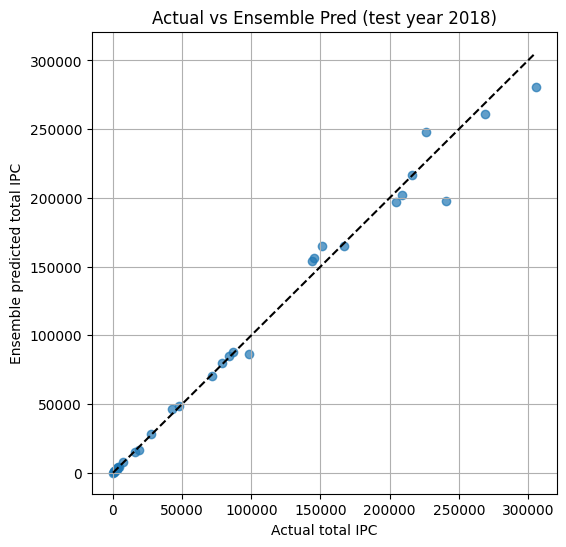

Forecasting completed. Forecast matrix now includes future years.


Year,2023,2024,2025,2026,2027,2028,2029,2030
States_UT,,,,,,,,
A&N Islands,226.076654,216.131509,226.076654,223.497349,216.174932,216.174932,203.553429,203.553429
Andhra Pradesh,170428.444362,166103.208534,165106.454933,165727.712984,165106.454933,165106.454933,165106.454933,165106.454933
Arunachal Pradesh,3013.775470,3345.786249,3750.515823,4555.014710,4858.971564,5100.847927,5464.535920,5983.499781
Assam,63567.011841,66589.406463,70595.352174,72650.596490,75855.676826,80553.248792,84653.028917,87220.994285
Bihar,215373.031618,220347.373134,244781.420683,260542.203646,260165.169260,255215.012288,255215.012288,255215.012288


Saved forecasts and artifacts to ncrb_global_ensemble_outputs_v2


,State,Predicted,z
18,Madhya Pradesh,261916.946912,1.612959
27,Rajasthan,256319.044027,1.558295
8,Delhi,255550.907233,1.550794
31,Uttar Pradesh,255432.403982,1.549636
19,Maharashtra,255344.040166,1.548773
4,Bihar,244781.420683,1.445628
29,Tamil Nadu,224638.686449,1.248930
16,Kerala,200321.245910,1.011466
10,Gujarat,184671.064424,0.858639
33,West Bengal,183381.782570,0.846049


Saved hotspot CSV.


,States_UT,mean_bias
1,Andhra Pradesh,-42860.872106
18,Madhya Pradesh,-24733.498878
3,Assam,-11745.274669
31,Uttar Pradesh,-8396.629605
16,Kerala,-7239.582420
27,Rajasthan,-6230.447779
12,Himachal Pradesh,-2757.660597
15,Karnataka,-1981.815816
6,Chhattisgarh,-1683.179885
32,Uttarakhand,-1085.930152


,States_UT,mean_bias
30,Tripura,586.451573
11,Haryana,1045.708916
13,Jammu & Kashmir,1068.916485
24,Odisha,1223.772800
8,Delhi,1568.726372
26,Punjab,3646.835800
4,Bihar,10839.404522
33,West Bengal,11432.880494
10,Gujarat,13393.024006
19,Maharashtra,22300.854777


XGBoost feature importance (gain):
[('log1p_lag_1', 2.1374928951263428),
 ('log1p_lag_3', 0.0022313958033919334),
 ('log1p_lag_2', 0.0009972820989787579),
 ('log1p_neighbor', 0.0005734987789765),
 ('state_idx', 0.0003744654532056302)]
CatBoost feature importance (feature_importances_):
[('log1p_lag_1', 40.66895756810146),
 ('log1p_lag_2', 36.04748484182056),
 ('log1p_lag_3', 17.95872294444155),
 ('log1p_neighbor', 4.731981528570599),
 ('state_idx', 0.5928531170658256)]
All artifacts saved in ncrb_global_ensemble_outputs_v2


In [6]:
# Full improved notebook/script for global IPC forecasting (XGB + CatBoost + Ridge stacking)
# – fixes: consistent state_idx mapping, defensive clipping before expm1, CatBoost categorical by name,
#          save mapping, safer XGBoost save, simple rolling CV helper, per-state diagnostics.

# Uncomment to install required packages (run locally if needed)
# !pip install --quiet pandas numpy matplotlib seaborn scikit-learn xgboost catboost joblib statsmodels openpyxl

import os
import json
import warnings
import math
from pprint import pprint

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from math import sqrt

import xgboost as xgb
from catboost import CatBoostRegressor, Pool
import joblib

# ---------------- Settings ----------------
SEED = 42
np.random.seed(SEED)
OUTPUT_DIR = "ncrb_global_ensemble_outputs_v2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Update filename if needed (place file in same directory or update path)
file_path = "Total IPC Crimes by State_UT(2011-2022).xlsx"
STATE_COL = "States_UT"

# ---------------- Load & clean ----------------
df_raw = pd.read_excel(file_path)
df_raw.columns = df_raw.columns.map(str)  # ensure column names are strings
print("Columns:", df_raw.columns.tolist())

# Detect year columns (strings that look like digits)
year_cols = [c for c in df_raw.columns if c.isdigit()]
year_cols = sorted([int(c) for c in year_cols])
print("Years detected:", year_cols)

# Keep only state + year cols
df_wide = df_raw[[STATE_COL] + [str(y) for y in year_cols]].copy()

# Melt to long, pivot to matrix states x years
df_long = df_wide.melt(id_vars=[STATE_COL], value_vars=[str(y) for y in year_cols],
                       var_name="Year", value_name="Total_IPC")
df_long["Year"] = df_long["Year"].astype(int)
df_long = df_long.sort_values([STATE_COL, "Year"]).reset_index(drop=True)

val_mat = df_long.pivot(index=STATE_COL, columns='Year', values='Total_IPC')
# forward/back fill across years within each state, then fill remaining with 0
val_mat = val_mat.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0)
val_mat = val_mat.sort_index()
states = val_mat.index.tolist()
years = list(val_mat.columns)
n_states = len(states)
print(f"States: {n_states}, Years range: {min(years)}-{max(years)}")
display(val_mat.head())

# ---------------- Spatial adjacency (correlation-based) ----------------
# Build correlation-based k-NN adjacency (on full history). If strict temporal separation is required,
# compute correlation matrix using only training years — see note below.
corr = val_mat.transpose().corr(method='pearson').fillna(0)
k = 4
A = np.zeros((n_states, n_states), dtype=float)
for i in range(n_states):
    row = corr.iloc[i].values
    # take top k neighbors excluding self
    neigh_idx = np.argsort(row)[- (k+1):]  # may include self
    neigh_idx = [j for j in neigh_idx if j != i][-k:]
    for j in neigh_idx:
        A[i, j] = corr.iloc[i, j]
        A[j, i] = corr.iloc[i, j]
# add self-loop for stability
A = A + np.eye(n_states)
deg = np.sum(A, axis=1)
D_inv_sqrt = np.diag(1.0 / (np.sqrt(deg + 1e-8)))
A_hat = D_inv_sqrt @ A @ D_inv_sqrt
print("Built normalized adjacency matrix A_hat.")

# ---------------- Build samples (lag features, neighbor aggregated value) ----------------
# Create a stable explicit mapping state -> index (use this mapping everywhere)
state_to_idx = {s: i for i, s in enumerate(states)}
idx_to_state = {i: s for s, i in state_to_idx.items()}
# persist mapping
with open(os.path.join(OUTPUT_DIR, "state_to_idx.json"), "w") as f:
    json.dump(state_to_idx, f, indent=2)

rows = []
lags = [1, 2, 3]
for s_idx, state in enumerate(states):
    series = val_mat.loc[state].astype(float)
    for t_idx, year in enumerate(years):
        target_year = year + 1
        if target_year not in years:
            continue
        # require presence of lag years; skip sample if we don't have full lag history
        ok = True
        lag_vals = {}
        for lag in lags:
            prev = year - lag
            if prev in years:
                lag_vals[f'lag_{lag}'] = float(series[prev])
            else:
                ok = False
                break
        if not ok:
            continue
        # neighbor aggregated value for the given year using A_hat and values in that year
        X_year = np.array([val_mat.loc[st, year] for st in states]).reshape(n_states, 1)
        neighbor_val = float((A_hat @ X_year)[s_idx, 0])
        rows.append({
            STATE_COL: state,
            'year': int(year),
            'lag_1': float(lag_vals['lag_1']),
            'lag_2': float(lag_vals['lag_2']),
            'lag_3': float(lag_vals['lag_3']),
            'neighbor': neighbor_val,
            'target_year': int(target_year),
            'target_raw': float(val_mat.loc[state, target_year])
        })

df_samples = pd.DataFrame(rows)
print("Samples shape:", df_samples.shape)
display(df_samples.head())

# log1p transform to stabilize variance
for c in ['lag_1', 'lag_2', 'lag_3', 'neighbor', 'target_raw']:
    df_samples[f'log1p_{c}'] = np.log1p(df_samples[c])

# use the fixed mapping
df_samples['state_idx'] = df_samples[STATE_COL].map(state_to_idx)

FEATURES = ['log1p_lag_1', 'log1p_lag_2', 'log1p_lag_3', 'log1p_neighbor', 'state_idx']
TARGET = 'log1p_target_raw'
df_samples[TARGET] = df_samples['log1p_target_raw'] = np.log1p(df_samples['target_raw'])

display(df_samples[FEATURES + [TARGET]].head())

# ---------------- Split: train / val / test (time-based) ----------------
target_years = sorted(df_samples['target_year'].unique())
if len(target_years) < 3:
    raise ValueError("Need at least 3 years of target to have train/val/test splits.")

test_year = max(target_years)
val_year = target_years[-2]
train_df = df_samples[df_samples['target_year'] < val_year].copy()
val_df = df_samples[df_samples['target_year'] == val_year].copy()
test_df = df_samples[df_samples['target_year'] == test_year].copy()
print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))

# ---------------- Prepare DMatrix / Pools ----------------
dtrain = xgb.DMatrix(train_df[FEATURES], label=train_df[TARGET])
dval = xgb.DMatrix(val_df[FEATURES], label=val_df[TARGET])
dtest = xgb.DMatrix(test_df[FEATURES], label=test_df[TARGET])

# CatBoost Pools (categorical by column name)
cat_features_param = ['state_idx']
train_pool = Pool(train_df[FEATURES], label=train_df[TARGET], cat_features=cat_features_param)
val_pool = Pool(val_df[FEATURES], label=val_df[TARGET], cat_features=cat_features_param)
test_pool = Pool(test_df[FEATURES], label=test_df[TARGET], cat_features=cat_features_param)

# ---------------- XGBoost training ----------------
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'seed': SEED,
    'verbosity': 0,
}
watch = [(dtrain, 'train'), (dval, 'val')]
xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=500, early_stopping_rounds=30, evals=watch, verbose_eval=50)
# save XGBoost in native format (more robust than joblib for Booster)
xgb_model.save_model(os.path.join(OUTPUT_DIR, 'xgb_global.json'))

# preds (log-space)
xgb_val_pred = xgb_model.predict(dval)
xgb_test_pred = xgb_model.predict(dtest)
# inverse transform safely (clip logs to avoid overflow when expm1)
def safe_expm1_array(log_arr, lower_clip=-50, upper_clip=50):
    clipped = np.clip(log_arr, lower_clip, upper_clip)
    raw = np.expm1(clipped)
    raw = np.maximum(0.0, raw)
    return raw

xgb_val_pred_raw = safe_expm1_array(xgb_val_pred)
xgb_test_pred_raw = safe_expm1_array(xgb_test_pred)

val_true_raw = val_df['target_raw'].values
test_true_raw = test_df['target_raw'].values

print("XGB Val RMSE (raw):", sqrt(mean_squared_error(val_true_raw, xgb_val_pred_raw)))
print("XGB Test RMSE (raw):", sqrt(mean_squared_error(test_true_raw, xgb_test_pred_raw)))

# ---------------- CatBoost training ----------------
cb = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=SEED,
    early_stopping_rounds=50,
    verbose=50
)
cb.fit(train_pool, eval_set=val_pool)
# save CatBoost
cb.save_model(os.path.join(OUTPUT_DIR, 'catboost_global.cbm'))

cb_val_pred = cb.predict(val_pool)
cb_test_pred = cb.predict(test_pool)
cb_val_pred_raw = safe_expm1_array(cb_val_pred)
cb_test_pred_raw = safe_expm1_array(cb_test_pred)

print("CatBoost Val RMSE (raw):", sqrt(mean_squared_error(val_true_raw, cb_val_pred_raw)))
print("CatBoost Test RMSE (raw):", sqrt(mean_squared_error(test_true_raw, cb_test_pred_raw)))

# ---------------- Ensemble stacking (Ridge) ----------------
ens_X_val = np.vstack([xgb_val_pred, cb_val_pred]).T  # log-space preds
ens_y_val = val_df[TARGET].values

stacker = Ridge(alpha=1.0, random_state=SEED)
stacker.fit(ens_X_val, ens_y_val)
print("Stacker coefs:", stacker.coef_, "intercept:", stacker.intercept_)

ens_X_test = np.vstack([xgb_test_pred, cb_test_pred]).T
ens_test_pred_log = stacker.predict(ens_X_test)
ens_test_pred_raw = safe_expm1_array(ens_test_pred_log)

print("Ensemble Test RMSE (raw):", sqrt(mean_squared_error(test_true_raw, ens_test_pred_raw)))

# persist stacker
joblib.dump(stacker, os.path.join(OUTPUT_DIR, 'stacker_ridge.joblib'))
# Save other artifacts
joblib.dump({'state_to_idx': state_to_idx}, os.path.join(OUTPUT_DIR, 'mappings.joblib'))

# prepare test_df with predictions for diagnostics & saving
test_df = test_df.reset_index(drop=True)
test_df['xgb_pred_raw'] = xgb_test_pred_raw
test_df['cb_pred_raw'] = cb_test_pred_raw
test_df['ens_pred_raw'] = ens_test_pred_raw
test_df['true_raw'] = test_true_raw

# ---------------- Per-state performance ----------------
state_perf = test_df.groupby(STATE_COL).apply(lambda g: sqrt(mean_squared_error(g['true_raw'], g['ens_pred_raw']))).reset_index()
state_perf.columns = [STATE_COL, 'rmse_ens']
state_perf = state_perf.sort_values('rmse_ens', ascending=False)
display(state_perf.head(15))
state_perf.to_csv(os.path.join(OUTPUT_DIR, "state_rmse_ens.csv"), index=False)

# overall metrics function
def metrics(true, pred):
    return {'rmse': sqrt(mean_squared_error(true, pred)), 'mae': np.mean(np.abs(true - pred)), 'r2': r2_score(true, pred)}

print("XGB Test metrics:", metrics(test_true_raw, xgb_test_pred_raw))
print("CatBoost Test metrics:", metrics(test_true_raw, cb_test_pred_raw))
print("Ensemble Test metrics:", metrics(test_true_raw, ens_test_pred_raw))

# scatter plot actual vs pred
plt.figure(figsize=(6, 6))
plt.scatter(test_true_raw, test_df['ens_pred_raw'], alpha=0.7)
mn = min(test_true_raw.min(), test_df['ens_pred_raw'].min())
mx = max(test_true_raw.max(), test_df['ens_pred_raw'].max())
plt.plot([mn, mx], [mn, mx], 'k--')
plt.xlabel("Actual total IPC")
plt.ylabel("Ensemble predicted total IPC")
plt.title(f"Actual vs Ensemble Pred (test year {test_year})")
plt.grid(True)
plt.show()

# ---------------- Forecast forward (2023..2030 or beyond) ----------------
future_years = list(range(max(years) + 1, 2031))  # e.g., 2023..2030 if history ends 2022
forecast_mat = val_mat.copy()  # start from historical matrix

for fy in future_years:
    # prepare feature dataframe for all states for predicting fy from previous years
    rows_f = []
    for s_idx, state in enumerate(states):
        # helper to get historical/predicted values from forecast_mat with fallback to last available
        def get_val(st, y):
            if y in forecast_mat.columns:
                return float(forecast_mat.loc[st, y])
            else:
                # fallback to last available value for that state
                return float(forecast_mat.loc[st].iloc[-1])
        l1 = get_val(state, fy - 1)
        l2 = get_val(state, fy - 2) if (fy - 2) in forecast_mat.columns else get_val(state, fy - 1)
        l3 = get_val(state, fy - 3) if (fy - 3) in forecast_mat.columns else get_val(state, fy - 1)
        rows_f.append([state, l1, l2, l3])
    feat_df = pd.DataFrame(rows_f, columns=[STATE_COL, 'lag_1', 'lag_2', 'lag_3'])
    # neighbor aggregation using A_hat and column fy-1 vector
    X_prev = np.array([ (forecast_mat.loc[st, fy-1] if (fy-1 in forecast_mat.columns) else forecast_mat.loc[st].iloc[-1]) for st in states ]).reshape(n_states, 1)
    neighbor_vals = (A_hat @ X_prev).reshape(n_states,)
    feat_df['neighbor'] = neighbor_vals
    feat_df['state_idx'] = feat_df[STATE_COL].map(state_to_idx)
    # log1p features
    for c in ['lag_1', 'lag_2', 'lag_3', 'neighbor']:
        feat_df[f'log1p_{c}'] = np.log1p(feat_df[c])
    X_feat = feat_df[['log1p_lag_1', 'log1p_lag_2', 'log1p_lag_3', 'log1p_neighbor', 'state_idx']]
    # predict with XGBoost & CatBoost
    dm = xgb.DMatrix(X_feat)
    xgb_pred_log = xgb_model.predict(dm)
    pool = Pool(X_feat, cat_features=['state_idx'])
    cb_pred_log = cb.predict(pool)
    # ensemble stacker (in log space)
    ens_log = stacker.predict(np.vstack([xgb_pred_log, cb_pred_log]).T)
    ens_raw = safe_expm1_array(ens_log)
    forecast_mat[fy] = ens_raw

print("Forecasting completed. Forecast matrix now includes future years.")
display(forecast_mat.iloc[:5, -len(future_years):])  # show snippet of newly added columns

# Save forecasts and artifacts
forecast_mat.to_excel(os.path.join(OUTPUT_DIR, "global_forecast_2023_2030_v2.xlsx"))
forecast_mat.to_excel(os.path.join(OUTPUT_DIR, "forecast_matrix_with_history_v2.xlsx"))
test_df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions_v2.csv"), index=False)
print("Saved forecasts and artifacts to", OUTPUT_DIR)

# ---------------- Hotspots analysis for a chosen future year ----------------
analyze_year = 2025
if analyze_year not in forecast_mat.columns:
    analyze_year = future_years[0]
vals = forecast_mat[analyze_year]
z = (vals - vals.mean()) / (vals.std() + 1e-8)
hotspots = pd.DataFrame({'State': forecast_mat.index, 'Predicted': vals.values, 'z': z.values})
hotspots = hotspots.sort_values('z', ascending=False)
display(hotspots.head(15))
hotspots.to_csv(os.path.join(OUTPUT_DIR, f"hotspots_{analyze_year}_v2.csv"), index=False)
print("Saved hotspot CSV.")

# ---------------- Extra diagnostics ----------------
# Per-state bias (mean residual)
state_bias = test_df.groupby(STATE_COL).apply(lambda g: (g['ens_pred_raw'] - g['true_raw']).mean()).reset_index()
state_bias.columns = [STATE_COL, 'mean_bias']
state_bias = state_bias.sort_values('mean_bias')
display(state_bias.head(10))
display(state_bias.tail(10))
state_bias.to_csv(os.path.join(OUTPUT_DIR, "state_bias_v2.csv"), index=False)

# Feature importance XGBoost (gain-based) and CatBoost
try:
    # XGBoost feature importance
    fmap = xgb_model.get_score(importance_type='gain')
    fx = sorted(fmap.items(), key=lambda x: x[1], reverse=True)
    print("XGBoost feature importance (gain):")
    pprint(fx)
except Exception as e:
    print("Could not extract XGBoost importances:", e)

try:
    print("CatBoost feature importance (feature_importances_):")
    pprint(list(zip(FEATURES, cb.get_feature_importance(prettified=False))))
except Exception as e:
    print("Could not extract CatBoost importances:", e)

# Save models with stable methods
cb.save_model(os.path.join(OUTPUT_DIR, 'catboost_global.cbm'))
xgb_model.save_model(os.path.join(OUTPUT_DIR, 'xgb_global.json'))
joblib.dump(stacker, os.path.join(OUTPUT_DIR, 'stacker_ridge.joblib'))
test_df.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions_v2.csv'), index=False)

print("All artifacts saved in", OUTPUT_DIR)


In [7]:
# pattern_analysis.py
"""
Pattern analysis for Total_IPC (states x years).
Produces plots:
 - national trend
 - top-k state trends
 - year-by-state heatmap
 - correlation matrix + hierarchical clustering
 - k-means clustering of states (by time-series)
 - anomalies / sudden jumps detection (simple z-score method)
Saves images & CSVs to outputs/pattern_analysis/.
"""

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set(style='whitegrid', font_scale=1.05)
OUTPUT = "outputs_pattern_analysis"
os.makedirs(OUTPUT, exist_ok=True)

# --- Load data (update filename/path if needed)
file_path = "Total IPC Crimes by State_UT(2011-2022).xlsx"
STATE_COL = "States_UT"
df_raw = pd.read_excel(file_path)
df_raw.columns = df_raw.columns.map(str)
year_cols = sorted([int(c) for c in df_raw.columns if c.isdigit()])
df_wide = df_raw[[STATE_COL] + [str(y) for y in year_cols]].copy()
df_wide = df_wide.set_index(STATE_COL).sort_index()

# create val_mat: states x years
val_mat = df_wide.copy()
val_mat.columns = [int(c) for c in val_mat.columns]
val_mat = val_mat.sort_index(axis=0).sort_index(axis=1)
val_mat = val_mat.apply(pd.to_numeric, errors='coerce').fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0)

# National (aggregate) trend
national = val_mat.sum(axis=0)
plt.figure(figsize=(10,4))
plt.plot(national.index, national.values, marker='o')
plt.title("National total IPC (sum across all states/UT) 2011-2022")
plt.xlabel("Year"); plt.ylabel("Total IPC")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "national_trend.png"))
plt.close()

# Top-K states by latest year and plot their trends
latest_year = max(val_mat.columns)
topk = 8
top_states = val_mat[latest_year].sort_values(ascending=False).head(topk).index.tolist()
plt.figure(figsize=(10,6))
for s in top_states:
    plt.plot(val_mat.columns, val_mat.loc[s].values, marker='o', label=s)
plt.legend(ncol=2, bbox_to_anchor=(1.0, 1.0))
plt.title(f"Top {topk} states by total IPC in {latest_year} - trends 2011-2022")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, f"top_{topk}_states_trends.png"))
plt.close()

# Heatmap: state x year (normalized)
plt.figure(figsize=(12,12))
data_norm = val_mat.div(val_mat.max(axis=1), axis=0)  # normalize per state for pattern view
sns.heatmap(data_norm, cmap='viridis', cbar_kws={'label':'Normalized crime intensity'})
plt.title("Heatmap (state x year) - normalized per state")
plt.xlabel("Year"); plt.ylabel("State/UT")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "heatmap_state_year_normalized.png"))
plt.close()

# Correlation matrix between states (time-series correlation)
corr = val_mat.transpose().corr()
plt.figure(figsize=(10,8))
sns.clustermap(corr, cmap='RdYlBu_r', linewidths=0.2, figsize=(12,12))
plt.suptitle("State-to-state correlation (hierarchical clustering)", y=1.02)
plt.savefig(os.path.join(OUTPUT, "state_correlation_clustermap.png"))
plt.close()

# Hierarchical clustering (dendrogram) and k-means for cluster labels
Z = linkage(val_mat.values, method='ward')
plt.figure(figsize=(12,4))
dendrogram(Z, labels=val_mat.index, leaf_rotation=90)
plt.title("Dendrogram of states by IPC time-series (Ward linkage)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "dendrogram_states.png"))
plt.close()

# pick k via elbow for k-means (range 2..8)
inertia = {}
X = val_mat.values  # states x years
for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia[k] = km.inertia_
# save inertia plot
plt.figure(figsize=(6,3))
plt.plot(list(inertia.keys()), list(inertia.values()), marker='o')
plt.title("K-means elbow (inertia) for state clustering")
plt.xlabel("k"); plt.ylabel("inertia")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "kmeans_elbow.png"))
plt.close()

# choose k=4 (example) and store cluster labels
k_choose = 4
km = KMeans(n_clusters=k_choose, random_state=42).fit(X)
clusters = pd.Series(km.labels_, index=val_mat.index, name='cluster').sort_values()
clusters.to_csv(os.path.join(OUTPUT, f"state_clusters_k{k_choose}.csv"))

# cluster centroid plots
plt.figure(figsize=(10,6))
for c in range(k_choose):
    centroid = km.cluster_centers_[c]
    plt.plot(val_mat.columns, centroid, label=f'cluster_{c}')
plt.legend()
plt.title(f"Cluster centroids (k={k_choose})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, f"k{k_choose}_cluster_centroids.png"))
plt.close()

# Simple anomaly detection per state using year-over-year % change z-score
pct_change = val_mat.pct_change(axis=1).replace([np.inf, -np.inf], np.nan).fillna(0)
# compute z-score across years for each state
z_scores = (pct_change.sub(pct_change.mean(axis=1), axis=0)).div(pct_change.std(axis=1)+1e-8, axis=0)
# flag anomalies where |z|>2.5
anom_mask = z_scores.abs() > 2.5
anomalies = []
for state in val_mat.index:
    yrs = list(val_mat.columns[anom_mask.loc[state].values])
    for y in yrs:
        anomalies.append({'state': state, 'year': int(y), 'pct_change': pct_change.loc[state, y], 'z': z_scores.loc[state, y]})
anomalies_df = pd.DataFrame(anomalies).sort_values(['z'], ascending=False)
anomalies_df.to_csv(os.path.join(OUTPUT, "anomalies_zscore.csv"), index=False)

# Save some summary tables
summary = pd.DataFrame({
    'state': val_mat.index,
    'latest_total': val_mat[latest_year].values,
    'mean_2011_2022': val_mat.mean(axis=1).values,
    'std_2011_2022': val_mat.std(axis=1).values
}).sort_values('latest_total', ascending=False)
summary.to_csv(os.path.join(OUTPUT, "state_summary_latest_mean_std.csv"), index=False)

print("Pattern analysis completed. Outputs in:", OUTPUT)


Pattern analysis completed. Outputs in: outputs_pattern_analysis


<Figure size 1000x800 with 0 Axes>

In [2]:
import pandas as pd

# Load your forecast matrix
df = pd.read_excel("ncrb_global_ensemble_outputs_v2/global_forecast_2023_2030_v2.xlsx", index_col=0)

forecast_results = []

for state in df.index:
    for year in df.columns:
        # Only keep future years (>= 2023)
        if int(year) >= 2023:
            forecast_results.append({
                "State": state,
                "Year": int(year),
                "Predicted": float(df.loc[state, year])
            })

forecast_df = pd.DataFrame(forecast_results)

# Save CSV for Streamlit
forecast_df.to_csv("forecast_results.csv", index=False)

print("forecast_results.csv CREATED successfully!")


forecast_results.csv CREATED successfully!


NATIONAL IPC ANALYSIS (2000–2022)

Crime columns: Index(['murder', 'attempt_to_commit_murder', 'ch_not_amounting_to_murder',
       'rape', 'kidnapping__abduction', 'dacoity',
       'preparation__assembly_for_dacoity', 'robbery',
       'burglary_housebreaking', 'theft', 'riots', 'criminal_breach_of_trust',
       'cheating', 'counterfeiting', 'arson', 'hurt', 'dowry_deaths',
       'molestation', 'sexual_harassment', 'cruelty_by_husband__relatives',
       'importation_of_girls', 'causing_death_by_negligence',
       'other_ipc_crimes', 'total_cognizable_crimes_under_ipc'],
      dtype='object')


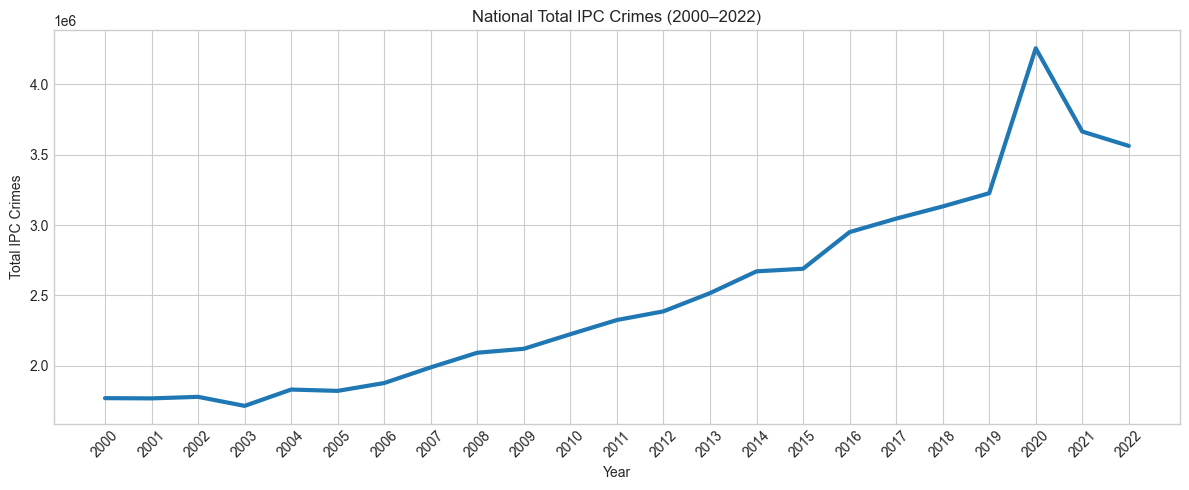


Top 5 crime contributors:
 total_cognizable_crimes_under_ipc    2.496523e+06
other_ipc_crimes                     8.465917e+05
theft                                4.657450e+05
hurt                                 4.376959e+05
causing_death_by_negligence          1.011283e+05
dtype: float64


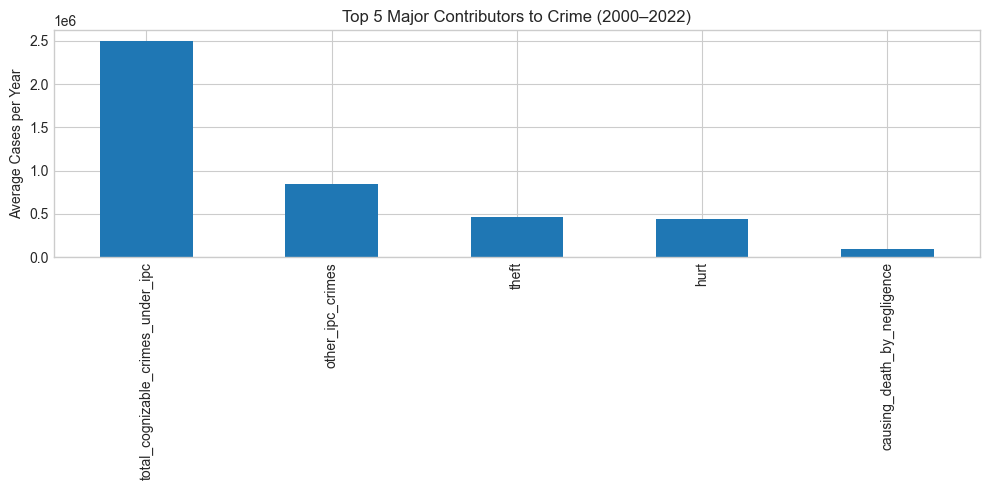

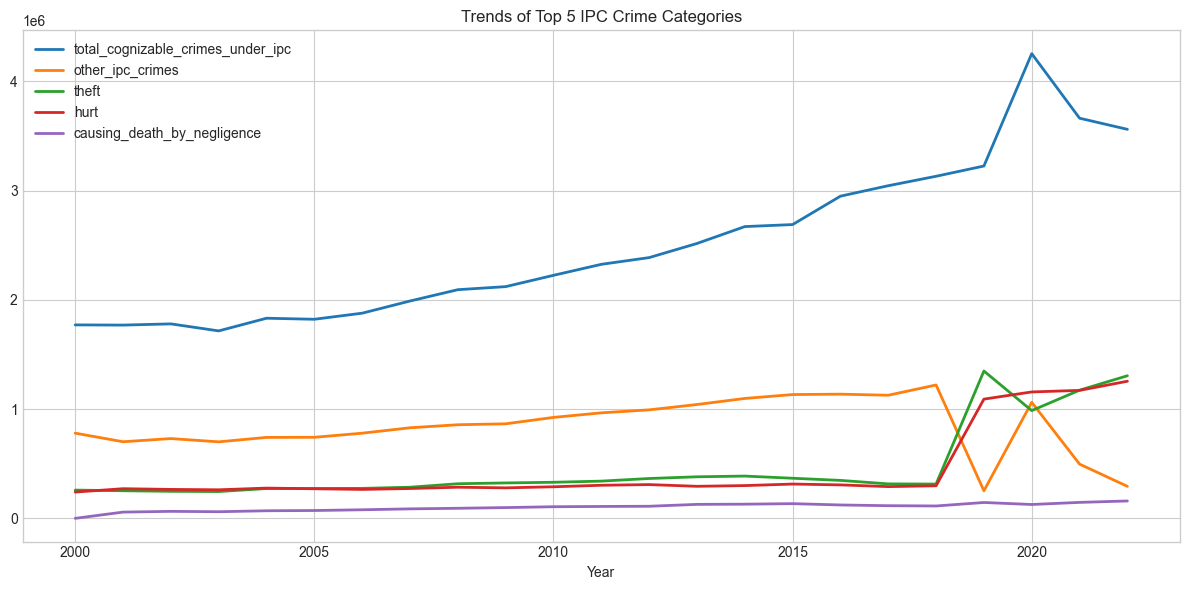

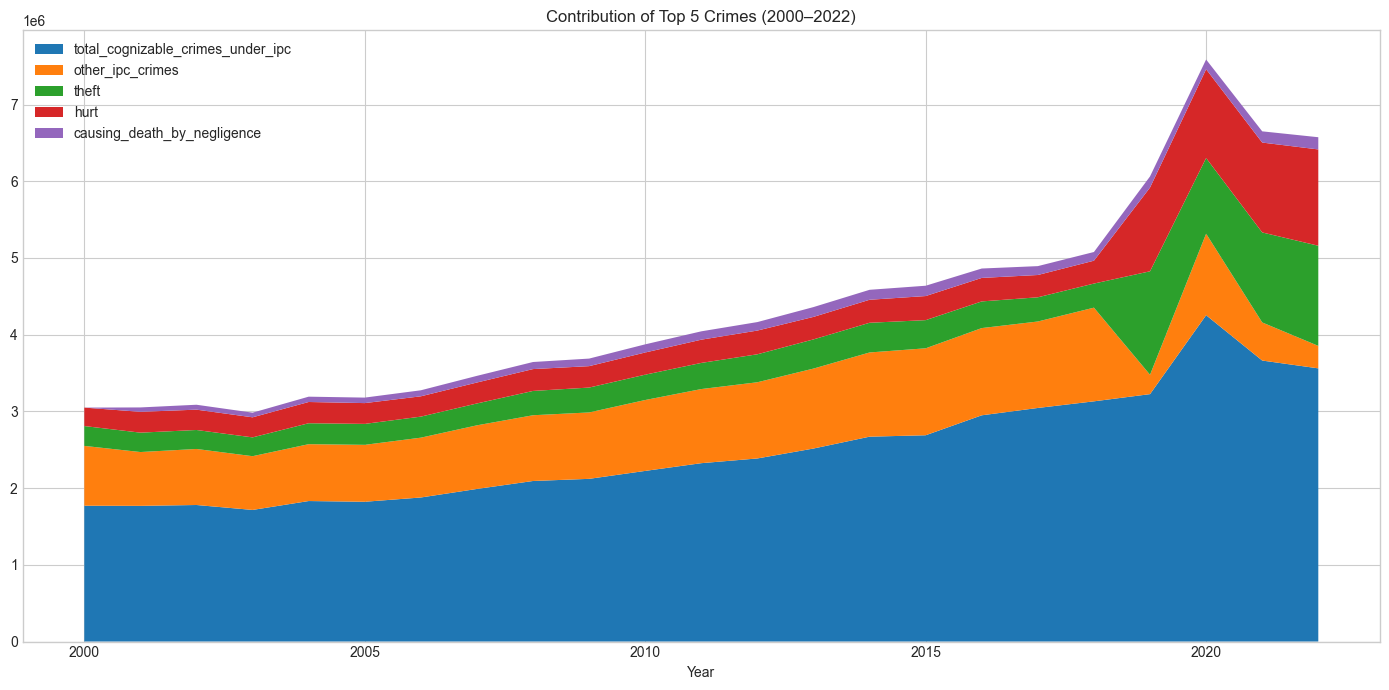

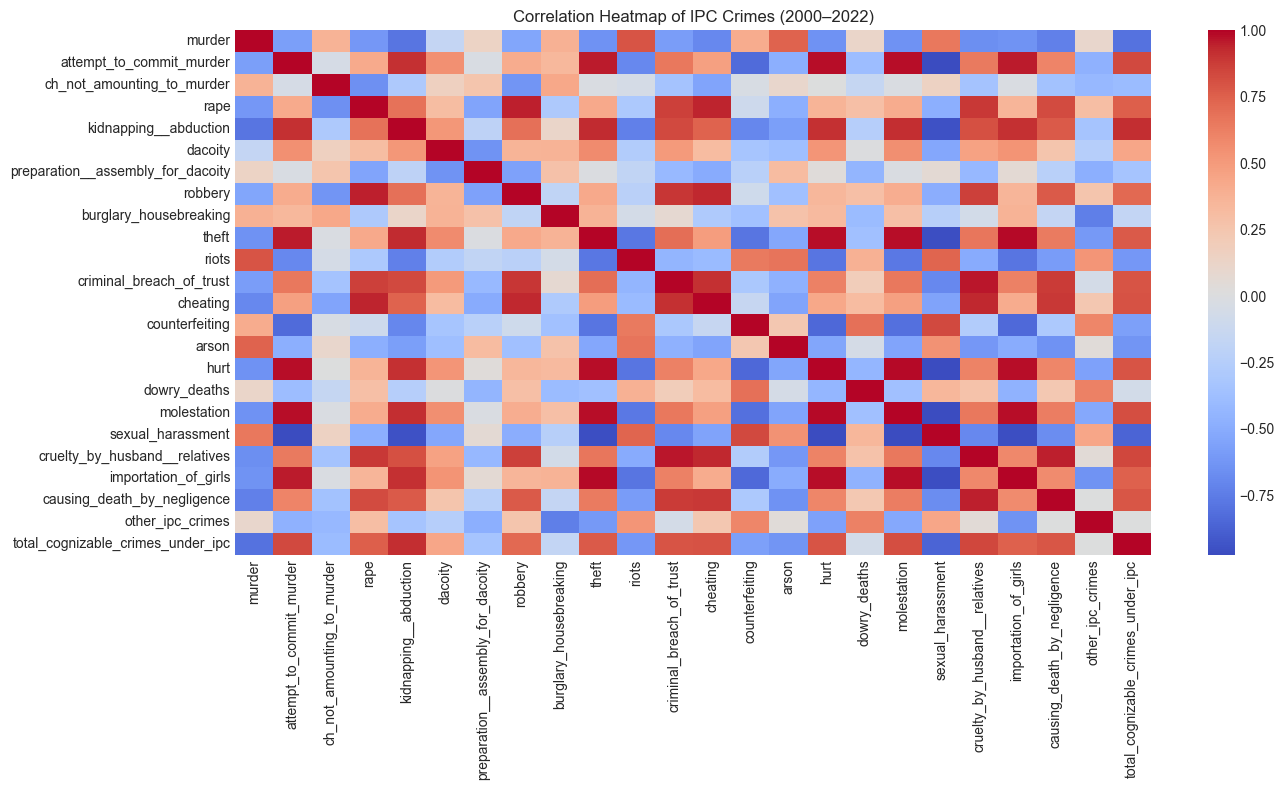

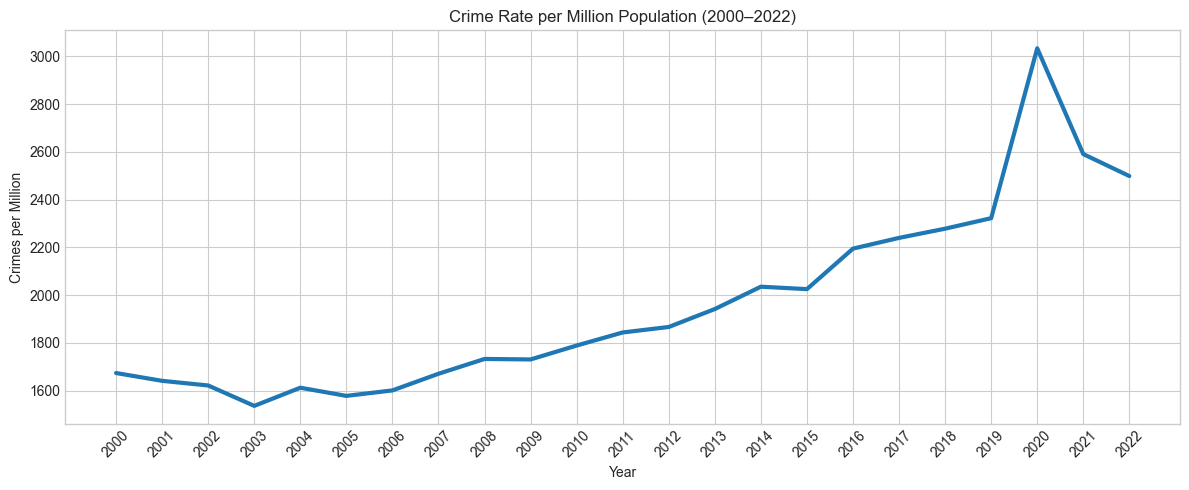

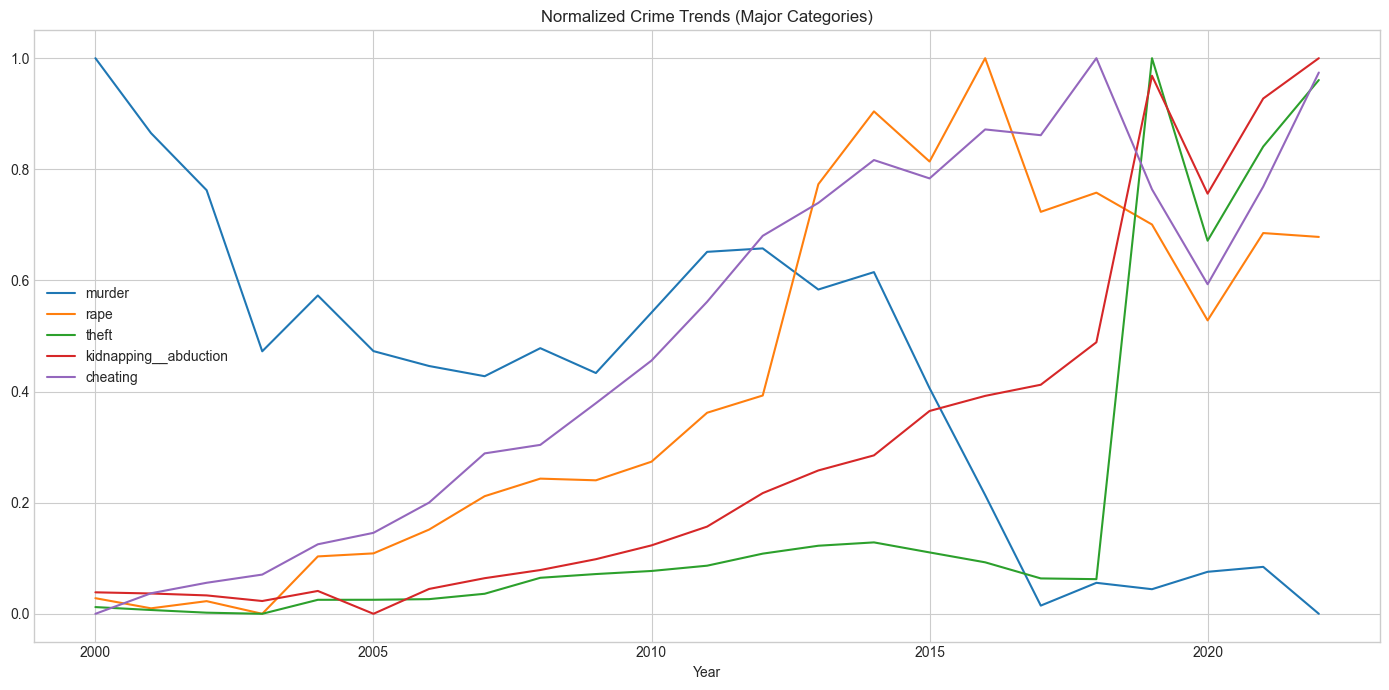

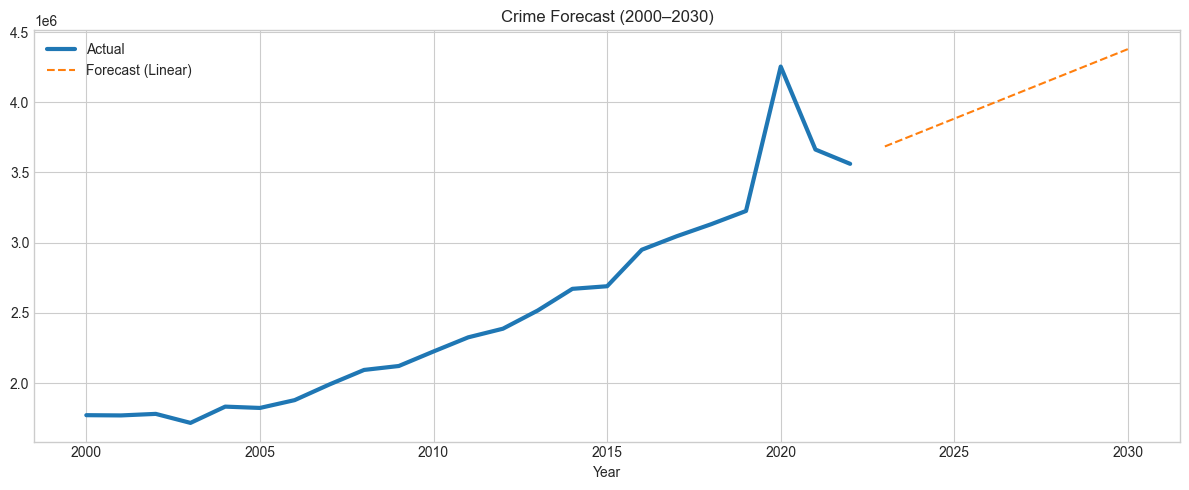


Forecast (2023–2030):

   year  forecast_total_crime
0  2023          3.685275e+06
1  2024          3.784337e+06
2  2025          3.883400e+06
3  2026          3.982463e+06
4  2027          4.081525e+06
5  2028          4.180588e+06
6  2029          4.279651e+06
7  2030          4.378713e+06


In [6]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-whitegrid")

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_excel("2000-22.xlsx")

df.head()
df.columns

# =========================
# 3. BASIC CLEANING
# =========================
df['year'] = df['year'].astype(int)

# Crime columns = exclude year, population, rate
crime_cols = df.columns.drop(['year', 'Population', 'total_crimes_per_million'])

print("Crime columns:", crime_cols)

# =========================
# 4. TOTAL CRIME TREND
# =========================
plt.figure(figsize=(12,5))
plt.plot(df['year'], df['total_cognizable_crimes_under_ipc'], linewidth=3)
plt.title("National Total IPC Crimes (2000–2022)")
plt.xlabel("Year")
plt.ylabel("Total IPC Crimes")
plt.xticks(df['year'], rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 5. TOP 5 CRIME CONTRIBUTORS
# =========================
top5 = df[crime_cols].mean().sort_values(ascending=False).head(5)

print("\nTop 5 crime contributors:\n", top5)

plt.figure(figsize=(10,5))
top5.plot(kind='bar')
plt.title("Top 5 Major Contributors to Crime (2000–2022)")
plt.ylabel("Average Cases per Year")
plt.tight_layout()
plt.show()

# =========================
# 6. TRENDS OF TOP 5 CRIMES
# =========================
plt.figure(figsize=(12,6))
for c in top5.index:
    plt.plot(df['year'], df[c], label=c, linewidth=2)

plt.title("Trends of Top 5 IPC Crime Categories")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 7. STACKED AREA CHART
# =========================
plt.figure(figsize=(14,7))
plt.stackplot(df['year'], df[top5.index].T, labels=top5.index)
plt.title("Contribution of Top 5 Crimes (2000–2022)")
plt.xlabel("Year")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# =========================
# 8. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(14,8))
sns.heatmap(df[crime_cols].corr(), cmap="coolwarm")
plt.title("Correlation Heatmap of IPC Crimes (2000–2022)")
plt.tight_layout()
plt.show()

# =========================
# 9. CRIME PER MILLION POPULATION
# =========================
plt.figure(figsize=(12,5))
plt.plot(df['year'], df['total_crimes_per_million'], linewidth=3)
plt.title("Crime Rate per Million Population (2000–2022)")
plt.xlabel("Year")
plt.ylabel("Crimes per Million")
plt.xticks(df['year'], rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 10. NORMALIZED CRIME PATTERN ANALYSIS
# =========================
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[crime_cols])
scaled_df = pd.DataFrame(scaled, columns=crime_cols)
scaled_df['year'] = df['year']

# Select few major categories for clarity
major_cols = ['murder', 'rape', 'theft', 'kidnapping__abduction', 'cheating']

plt.figure(figsize=(14,7))
for c in major_cols:
    plt.plot(scaled_df['year'], scaled_df[c], label=c)

plt.title("Normalized Crime Trends (Major Categories)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11. LINEAR FORECASTING UP TO 2030
# =========================
from sklearn.linear_model import LinearRegression

X = df[['year']]
y = df['total_cognizable_crimes_under_ipc']

model = LinearRegression().fit(X, y)

future_years = pd.DataFrame({'year': np.arange(2023, 2031)})
forecast = model.predict(future_years)

plt.figure(figsize=(12,5))
plt.plot(df['year'], y, label="Actual", linewidth=3)
plt.plot(future_years['year'], forecast, label="Forecast (Linear)", linestyle="--")
plt.title("Crime Forecast (2000–2030)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

print("\nForecast (2023–2030):\n")
print(pd.DataFrame({"year": future_years['year'], "forecast_total_crime": forecast}))


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, joblib

# filenames (update if different)
FORECAST_FILE = "forecast_results.csv"       # your forecast outputs (state, Year, Predicted)
TEST_PRED_FILE = "test_predictions_v2.csv"   # test set preds created earlier
MAPPINGS_FILE = "mappings.joblib"            # contains state_to_idx maybe
MODEL_XGB = "ncrb_global_ensemble_outputs_v2/xgb_global.json"
MODEL_CB  = "ncrb_global_ensemble_outputs_v2/catboost_global.cbm"
STACKER_FILE = "ncrb_global_ensemble_outputs_v2/stacker_ridge.joblib"

# load forecast
if not os.path.exists(FORECAST_FILE):
    print("No forecast_results.csv found. Please provide the file path.")
else:
    fc = pd.read_csv(FORECAST_FILE)
    print("Forecast file loaded:", fc.shape)
    # quick stats
    print(fc.groupby('Year')['Predicted'].agg(['mean','min','max','std']).round(3))

    # examine single state (Delhi)
    state = "Delhi"
    sfc = fc[fc['State'].str.lower().str.contains(state.lower())]  # fuzzy
    if sfc.empty:
        print("State not found exact; listing unique states sample:", fc['State'].unique()[:30])
    else:
        print("Forecast for", state)
        print(sfc.sort_values('Year').to_string(index=False))

    # check if predictions are almost constant
    if not sfc.empty:
        vals = sfc.sort_values('Year')['Predicted'].values
        print("Predicted diff stats: min diff:", np.min(np.diff(vals)) if len(vals)>1 else None,
              "std:", np.std(vals))
        if np.std(vals) < 1e-6:
            print("WARNING: predictions are constant (std ~= 0).")

# check test predictions and compare actual vs ensemble if available
if os.path.exists(TEST_PRED_FILE):
    td = pd.read_csv(TEST_PRED_FILE)
    print("\nTest preds shape:", td.shape)
    # check some rows for the same state
    same = td[td['State'].str.lower().str.contains(state.lower())]
    if not same.empty:
        print("Test rows for", state, ":\n", same[['year','true_raw','ens_pred_raw','xgb_pred_raw','cb_pred_raw']].head().to_string(index=False))
        # plot history + test pred
        try:
            hist = pd.read_excel("Total IPC Crimes by State_UT(2011-2022).xlsx").set_index('States_UT')
            years = [str(y) for y in range(2011, 2023)]
            ser = hist.loc[state, years].astype(float)
            plt.figure(figsize=(8,4))
            plt.plot(list(map(int,years)), ser.values, label='history')
        except Exception:
            pass
        # overlay test predicted year(s)
        plt.scatter(same['year'], same['ens_pred_raw'], color='red', label='ens_pred_test')
        plt.title(f"{state} history + test preds")
        plt.legend()
        plt.show()
    else:
        print("No test rows for", state)

# If models exist, check stacker output range (log-space)
if os.path.exists(STACKER_FILE):
    stacker = joblib.load(STACKER_FILE)
    print("\nLoaded stacker:", type(stacker), "coef:", getattr(stacker,'coef_', None))
else:
    print("\nStacker not found at", STACKER_FILE)


Forecast file loaded: (272, 3)
            mean     min         max         std
Year                                            
2023   92492.410  81.118  269916.216   99211.103
2024   94842.068  71.790  276193.319  101622.204
2025   96742.467  75.563  261916.947  102404.631
2026   99084.136  81.118  268729.618  104603.229
2027  101194.538  88.087  269916.216  106608.278
2028  102559.149  91.660  278507.658  107675.699
2029  103860.385  91.660  280837.173  108323.788
2030  105962.437  91.660  278973.854  110181.286
Forecast for Delhi
State  Year     Predicted
Delhi  2023 256527.420649
Delhi  2024 255550.907233
Delhi  2025 255550.907233
Delhi  2026 255550.907233
Delhi  2027 255550.907233
Delhi  2028 255550.907233
Delhi  2029 255550.907233
Delhi  2030 255550.907233
Predicted diff stats: min diff: -976.5134160871967 std: 322.95145636060784

Loaded stacker: <class 'sklearn.linear_model._ridge.Ridge'> coef: [0.49027539 0.50580116]
